# The CMB power spectrum — fitting cosmology to Planck

The cosmic microwave background's tiny temperature ripples, summarized as a **power
spectrum** (variance vs angular scale ℓ), encode the contents and geometry of the
Universe. We fit a ΛCDM model — its theory spectrum computed by **CAMB** — to the real
**Planck 2018** TT and TE spectra, and read off cosmological parameters including the
Hubble constant *from the early Universe*.

> Heads-up: this is the most ambitious demo. The theory is a Boltzmann code (CAMB), the
> likelihood is a simplified Gaussian on binned data, and the fit takes ~20 s. See
> `notes/NOTES_cmb.md` for the honest list of simplifications.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
from scripts.cmb import load_planck
data = load_planck("data/real/planck_tt_binned.csv", "data/real/planck_te_binned.csv")
l_tt, D_tt, e_tt = data["tt"]
print(len(l_tt), "TT bins,", len(data["te"][0]), "TE bins")

83 TT bins, 66 TE bins


## 1. The acoustic peaks

Plot the TT spectrum: D_ℓ = ℓ(ℓ+1)C_ℓ/2π vs multipole ℓ. The peaks are **sound waves**
frozen into the plasma at recombination — their spacing and heights are a fingerprint of
the cosmology.

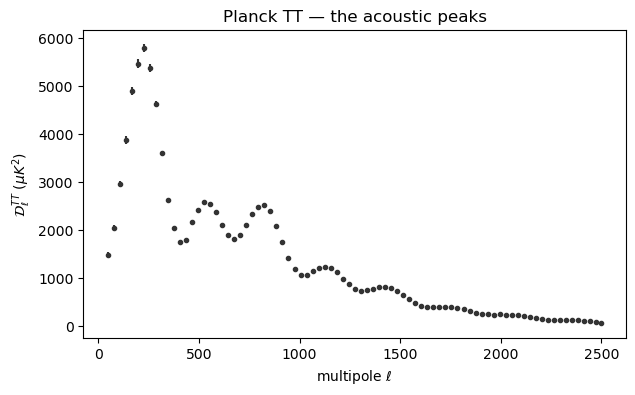

In [2]:
fig, ax = plt.subplots(figsize=(7,4))
ax.errorbar(l_tt, D_tt, yerr=e_tt, fmt="o", ms=3, color="0.2")
ax.set_xlabel(r"multipole $\ell$"); ax.set_ylabel(r"$\mathcal{D}_\ell^{TT}$ ($\mu K^2$)")
ax.set_title("Planck TT — the acoustic peaks"); plt.show()

## 2. The units trap

CAMB (and theory) naturally give the angular power C_ℓ. Plot that raw and it looks
*nothing* like the data — it falls off steeply. The spectrum everyone plots is
**D_ℓ = ℓ(ℓ+1)C_ℓ/2π**, in **μK²**. Getting this factor (and the μK vs K scale) wrong is
the classic first CMB bug; `tests/test_cmb.py::test_normalization_matches_camb` guards it.

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_36935/2721790900.py:4: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(ell, Dtt_fid, "-", color="crimson", label="theory $\mathcal{D}_\ell$ (correct)")


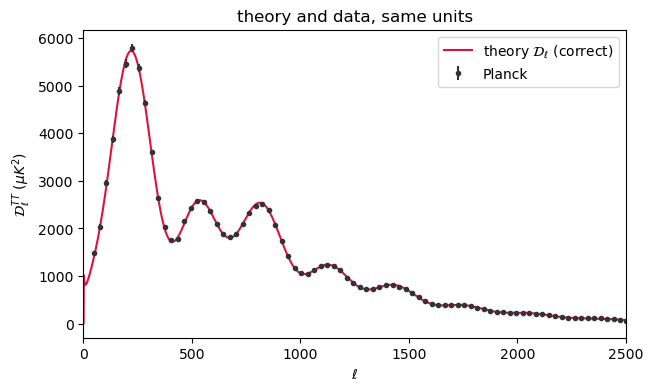

In [3]:
from scripts.cmb import theory_spectrum
ell, Dtt_fid, _ = theory_spectrum(67.36, 0.120, 2.10)   # D_ell, correct normalization
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ell, Dtt_fid, "-", color="crimson", label="theory $\mathcal{D}_\ell$ (correct)")
ax.errorbar(l_tt, D_tt, yerr=e_tt, fmt="o", ms=3, color="0.2", label="Planck")
ax.set_xlim(0,2500); ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$\mathcal{D}_\ell^{TT}$ ($\mu K^2$)")
ax.legend(); ax.set_title("theory and data, same units"); plt.show()

## 3. Fit the cosmology

Minimize the joint TT+TE χ² over three parameters — the Hubble constant **H₀**, the cold
dark matter density **ωc**, and the primordial amplitude **Aₛ** — holding ωb, nₛ, τ at the
Planck fiducial. (~20 s: each step calls CAMB.)

In [4]:
from scripts.cmb import fit_cosmology
fit = fit_cosmology(data)
print(f"H0     = {fit['H0']:.2f} km/s/Mpc   (Planck 67.36)")
print(f"omch2  = {fit['omch2']:.4f}         (Planck 0.1200)")
print(f"As/1e-9= {fit['As']:.3f}            (Planck 2.100)")
print(f"chi2/dof = {fit['chi2']/fit['ndof']:.2f}")

H0     = 67.02 km/s/Mpc   (Planck 67.36)
omch2  = 0.1207         (Planck 0.1200)
As/1e-9= 2.104            (Planck 2.100)
chi2/dof = 1.09


## 4. The fit, and the second probe (TE)

Overlay the best fit on TT — and on TE, the temperature–polarization cross-spectrum.
The same three parameters, fit jointly, track *both* spectra. One cosmology, two
independent observables: that consistency is the real evidence.

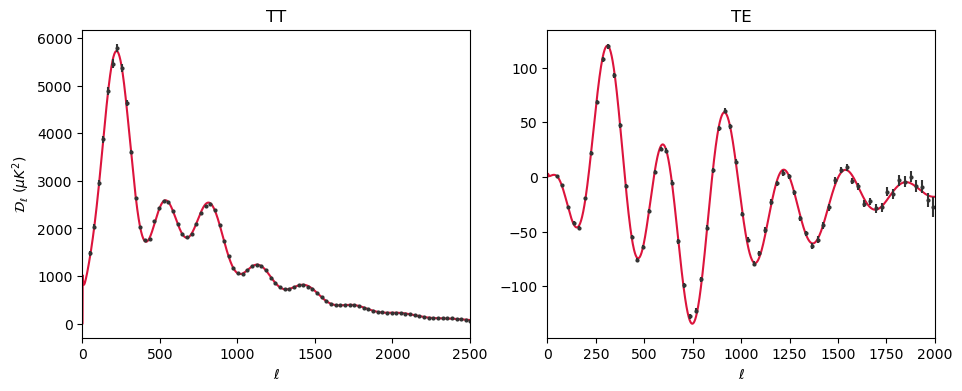

In [5]:
ell, Dtt, Dte = theory_spectrum(fit["H0"], fit["omch2"], fit["As"])
l_te, D_te, e_te = data["te"]
fig, (a0,a1) = plt.subplots(1,2, figsize=(11,4))
a0.plot(ell, Dtt, "-", color="crimson"); a0.errorbar(l_tt, D_tt, yerr=e_tt, fmt="o", ms=2, color="0.2")
a0.set_xlim(0,2500); a0.set_title("TT"); a0.set_xlabel(r"$\ell$"); a0.set_ylabel(r"$\mathcal{D}_\ell\ (\mu K^2)$")
a1.plot(ell, Dte, "-", color="crimson"); a1.errorbar(l_te, D_te, yerr=e_te, fmt="o", ms=2, color="0.2")
a1.set_xlim(0,2000); a1.set_title("TE"); a1.set_xlabel(r"$\ell$")
plt.show()

## Result — and the Hubble tension, again

From the CMB acoustic peaks, **H₀ ≈ 67 km/s/Mpc** — the expansion rate inferred from the
*early* Universe. Compare demo `05_hubble`, where *local* galaxies gave **74.8**. Two
rigorous measurements, ~5σ apart: the **Hubble tension**, one of the sharpest open
problems in cosmology — and you've now measured both sides of it in this repo.

Our ωc and Aₛ also match Planck 2018, with χ²/dof ≈ 1.1. See `notes/HANDOFF_cmb.md` for
the parameters and the (important) list of simplifications.